# Notebook 02: Exploratory Data Analysis on Smoothed Technical Features

This notebook covers **Chapter 3 (Exploratory Data Analysis)** based on the output of Notebook 01.

Focus areas:
1. Statistical summary using full dataset structure (`pandas.info()` + descriptive tables).
2. Correlation analysis with next-day return label.
3. Trend and pattern discovery with rich visuals (histograms, box plots, time-series, scatter plots).

The notebook prioritizes interpretability and report-ready explanations.


In [24]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

In [25]:
DATA_PARQUET = Path("../data/processed/aapl_features_smoothed.parquet")
DATA_CSV = Path("../data/processed/aapl_features_smoothed.csv")

if DATA_PARQUET.exists():
    df = pd.read_parquet(DATA_PARQUET)
elif DATA_CSV.exists():
    df = pd.read_csv(DATA_CSV, index_col=0, parse_dates=True)
else:
    raise FileNotFoundError("Run Notebook 01 first to generate processed feature data.")

if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

df = df.sort_index()
df.head()

,adj_close,adj_close_smooth,rsi_14,macd_hist_12_26_9,bb_bandwidth_20_2,adx_14,atr_14,obv,roc_10,target_ret_1d_pct
Date,,,,,,,,,,
2021-05-27,122.229416,123.247685,31.926834,0.170177,7.415559,55.268885,4.395619,-5.688121e+08,-0.723586,-0.534784
2021-05-28,121.575752,122.913298,29.701025,0.171716,6.849811,54.934163,4.372074,-6.457471e+08,-1.024920,-0.264848
2021-06-01,121.253761,122.581391,27.641150,0.160694,6.134840,54.865161,4.346043,-7.208225e+08,-1.134432,0.627642
2021-06-02,122.014801,122.468073,26.953833,0.155960,5.571166,54.967599,4.321565,-7.927386e+08,-0.877575,-1.215428
2021-06-03,120.531799,122.080818,24.694009,0.137577,5.152103,55.326148,4.282148,-8.655174e+08,-0.886408,1.902218


## 1) Statistical Summary (Full Dataset Structure)

The assignment guideline asks for statistical summarization and clear dataset inspection. We therefore include:
- `df.info()` to show data types, non-null counts, and memory usage.
- Missing-value table.
- Descriptive statistics for all numeric fields.


In [26]:
buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1222 entries, 2021-05-27 to 2026-04-09
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adj_close          1222 non-null   float64
 1   adj_close_smooth   1222 non-null   float64
 2   rsi_14             1222 non-null   float64
 3   macd_hist_12_26_9  1222 non-null   float64
 4   bb_bandwidth_20_2  1222 non-null   float64
 5   adx_14             1222 non-null   float64
 6   atr_14             1222 non-null   float64
 7   obv                1222 non-null   float64
 8   roc_10             1222 non-null   float64
 9   target_ret_1d_pct  1222 non-null   float64
dtypes: float64(10)
memory usage: 105.0 KB



### Insight Justification: Dataset Structure

`df.info()` verifies data types, non-null coverage, and memory footprint.
This is important because reliable preprocessing and valid EDA conclusions depend on clean, numerically consistent inputs.


In [27]:
missing_tbl = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3),
}).sort_values("missing_count", ascending=False)
missing_tbl

,missing_count,missing_pct
adj_close,0,0.0
adj_close_smooth,0,0.0
rsi_14,0,0.0
macd_hist_12_26_9,0,0.0
bb_bandwidth_20_2,0,0.0
adx_14,0,0.0
atr_14,0,0.0
obv,0,0.0
roc_10,0,0.0
target_ret_1d_pct,0,0.0


In [28]:
desc_tbl = df.describe().T
desc_tbl

,count,mean,std,min,25%,50%,75%,max
adj_close,1222.0,1.881989e+02,4.109384e+01,1.205318e+02,1.530453e+02,1.781032e+02,2.222362e+02,2.859225e+02
adj_close_smooth,1222.0,1.877649e+02,4.080332e+01,1.220808e+02,1.525557e+02,1.775025e+02,2.218637e+02,2.792980e+02
rsi_14,1222.0,5.791353e+01,2.724204e+01,6.750563e+00,3.410242e+01,5.862145e+01,8.481839e+01,9.878123e+01
macd_hist_12_26_9,1222.0,-1.991314e-03,8.075916e-01,-2.457549e+00,-5.020300e-01,6.073499e-02,5.272664e-01,2.228849e+00
bb_bandwidth_20_2,1222.0,8.159467e+00,3.964532e+00,1.766143e+00,5.029305e+00,7.370454e+00,1.062484e+01,2.063256e+01
adx_14,1222.0,5.127966e+01,1.826858e+01,1.782681e+01,3.714802e+01,4.959368e+01,6.433239e+01,9.424040e+01
atr_14,1222.0,4.572451e+00,9.277995e-01,2.883482e+00,3.907156e+00,4.486386e+00,5.099624e+00,9.030788e+00
obv,1222.0,5.683449e+09,3.161909e+09,-8.655174e+08,2.809966e+09,5.931724e+09,8.238733e+09,1.175527e+10
roc_10,1222.0,6.650000e-01,3.919386e+00,-1.057344e+01,-2.283494e+00,1.019796e+00,3.346442e+00,1.001249e+01
target_ret_1d_pct,1222.0,7.690609e-02,1.735214e+00,-9.245617e+00,-7.580780e-01,1.114528e-01,9.508155e-01,1.532885e+01


### Insight Justification: Descriptive Statistics

Descriptive statistics summarize center, spread, and extremes for each variable.
These summaries help identify volatility intensity, outlier risk, and scale differences that affect model behavior and interpretation quality.


## 2) Target Distribution Analysis

A good regression study should inspect the label distribution for:
- central tendency,
- volatility,
- skewness/outliers.

This supports downstream model/metric interpretation.


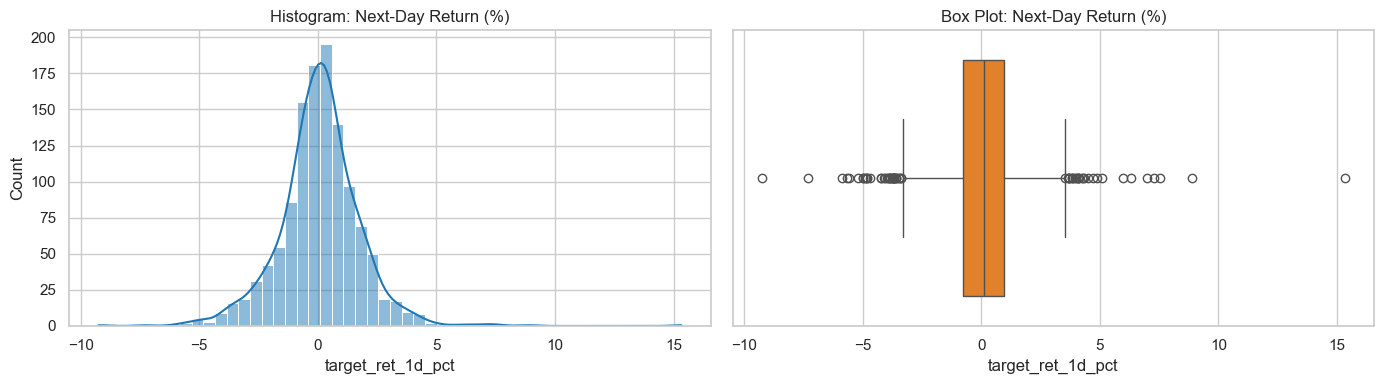

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["target_ret_1d_pct"], bins=50, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Histogram: Next-Day Return (%)")
axes[0].set_xlabel("target_ret_1d_pct")

sns.boxplot(x=df["target_ret_1d_pct"], ax=axes[1], color="#ff7f0e")
axes[1].set_title("Box Plot: Next-Day Return (%)")
axes[1].set_xlabel("target_ret_1d_pct")

plt.tight_layout()
plt.show()

### Insight Justification: Target Distribution

Histogram and box plot of `target_ret_1d_pct` show whether returns are symmetric, heavy-tailed, or outlier-prone.
This directly supports discussion on forecast difficulty and the suitability/limitations of linear models.


## 3) Feature Distribution Analysis (Histogram + Box Plot)

Each selected feature is visualized using:
- histogram (shape/distribution), and
- box plot (spread/outliers).

This helps assess scaling, heavy tails, and regime behavior before modeling.


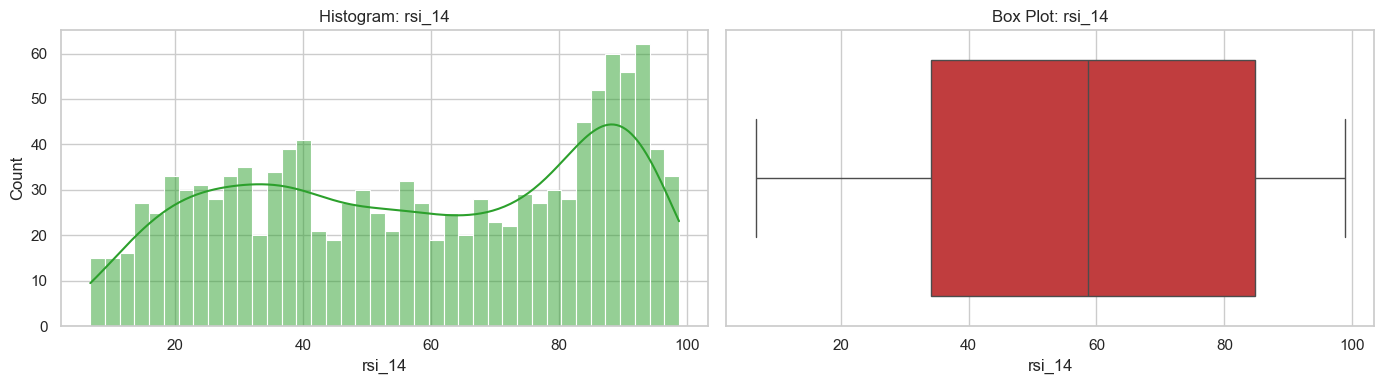

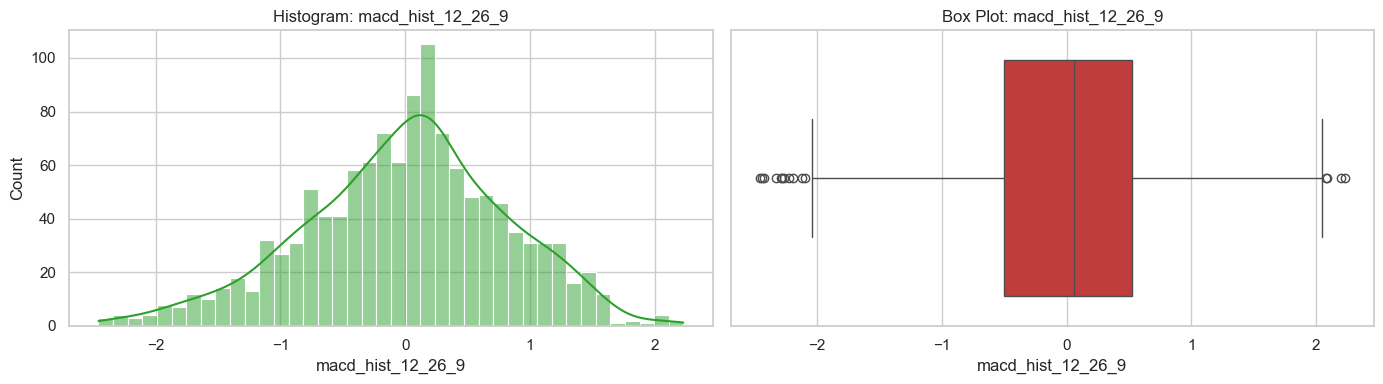

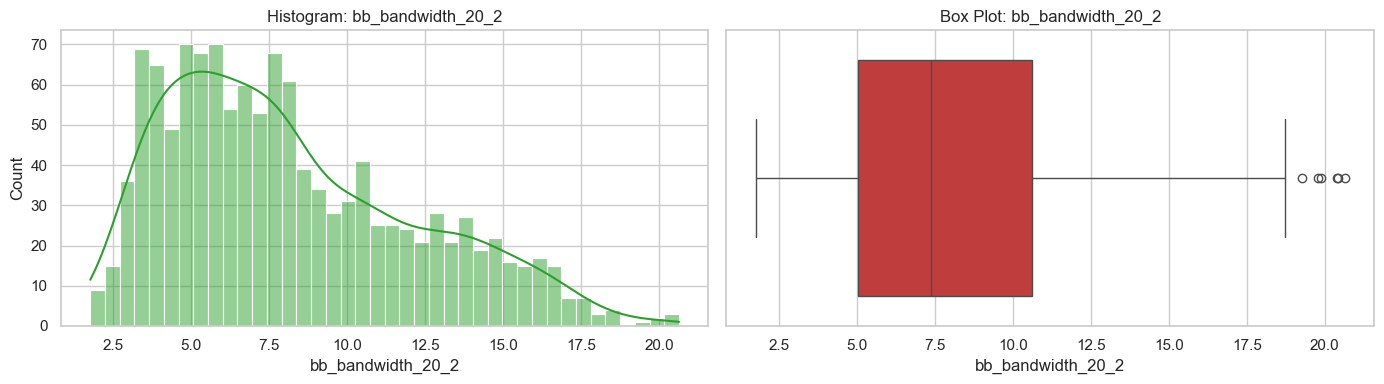

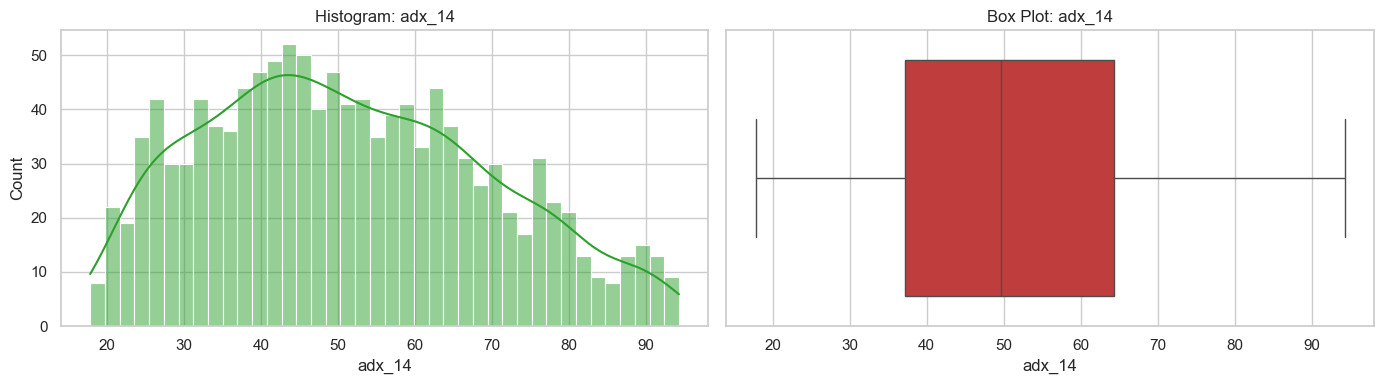

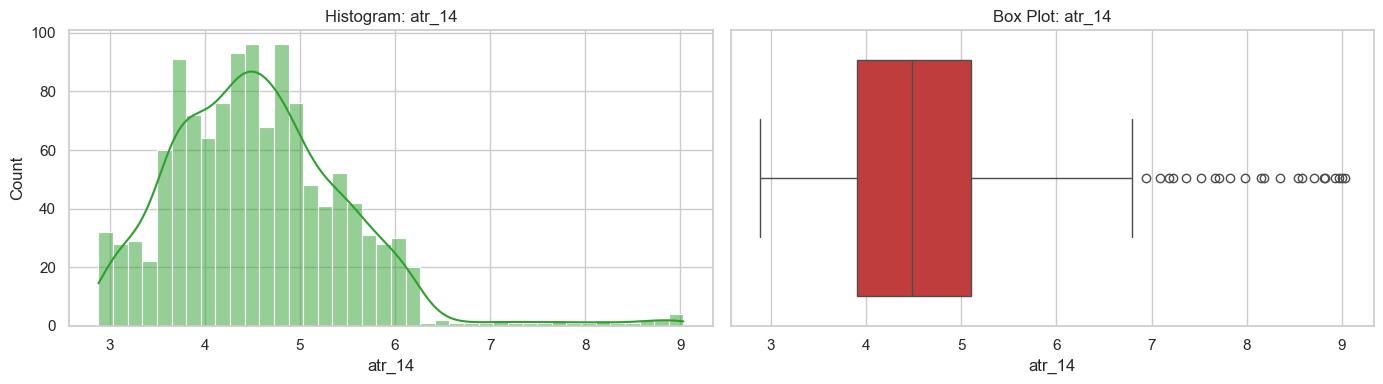

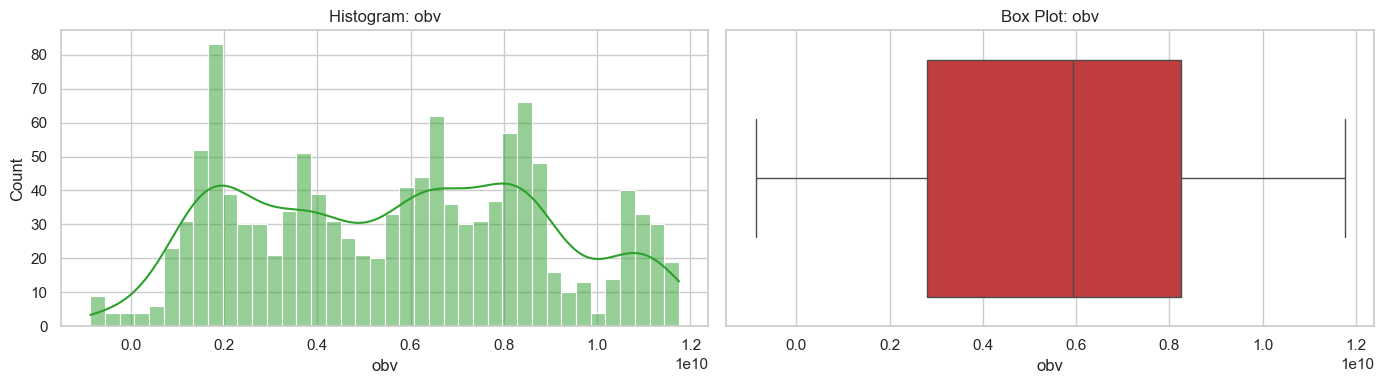

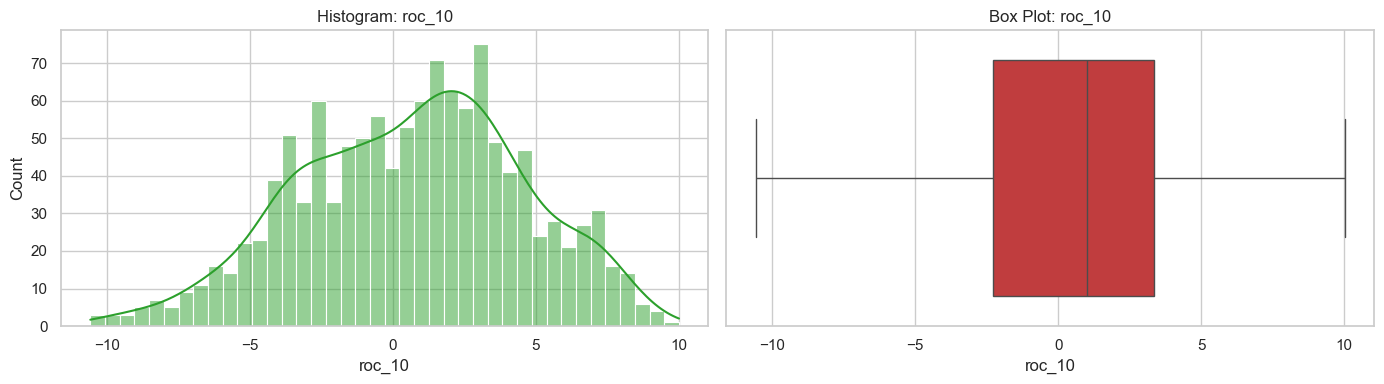

In [ ]:
feature_cols = [
    "rsi_14",
    "macd_hist_12_26_9",
    "bb_pctb_20_2",
    "bb_bandwidth_20_2",
    "adx_14",
    "atr_14",
    "obv",
    "roc_10",
]

for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[col], bins=40, kde=True, ax=axes[0], color="#2ca02c")
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[1], color="#d62728")
    axes[1].set_title(f"Box Plot: {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

### Insight Justification: Feature Distributions

Feature-wise histograms and box plots reveal each indicator's shape, spread, and extreme behavior.
This supports interpretation of market regimes and highlights whether transformation/scaling may be needed in later modeling chapters.


## 4) Correlation Analysis with Target

We compute Pearson and Spearman correlations between each feature and `target_ret_1d_pct`.
- Pearson: linear relationships.
- Spearman: monotonic relationships, robust to non-normality.

A feature-feature heatmap is also included to inspect remaining multicollinearity.


In [ ]:
pearson = df[feature_cols + ["target_ret_1d_pct"]].corr(method="pearson")
spearman = df[feature_cols + ["target_ret_1d_pct"]].corr(method="spearman")

corr_tbl = pd.DataFrame({
    "pearson_with_target": pearson["target_ret_1d_pct"].drop("target_ret_1d_pct"),
    "spearman_with_target": spearman["target_ret_1d_pct"].drop("target_ret_1d_pct"),
})
corr_tbl["abs_pearson"] = corr_tbl["pearson_with_target"].abs()
corr_tbl = corr_tbl.sort_values("abs_pearson", ascending=False)
corr_tbl

,pearson_with_target,spearman_with_target,abs_pearson
roc_10,-0.041938,-0.030734,0.041938
macd_hist_12_26_9,-0.037514,-0.018334,0.037514
bb_bandwidth_20_2,0.033118,0.043717,0.033118
adx_14,0.032697,0.031869,0.032697
obv,-0.032647,-0.045195,0.032647
atr_14,-0.026363,-0.030051,0.026363
rsi_14,-0.015065,-0.032774,0.015065


### Insight Justification: Feature-Target Correlation

Pearson and Spearman values quantify linear and monotonic relationships with the next-day return label.
Even modest correlations are informative in finance, where signal-to-noise is usually low.


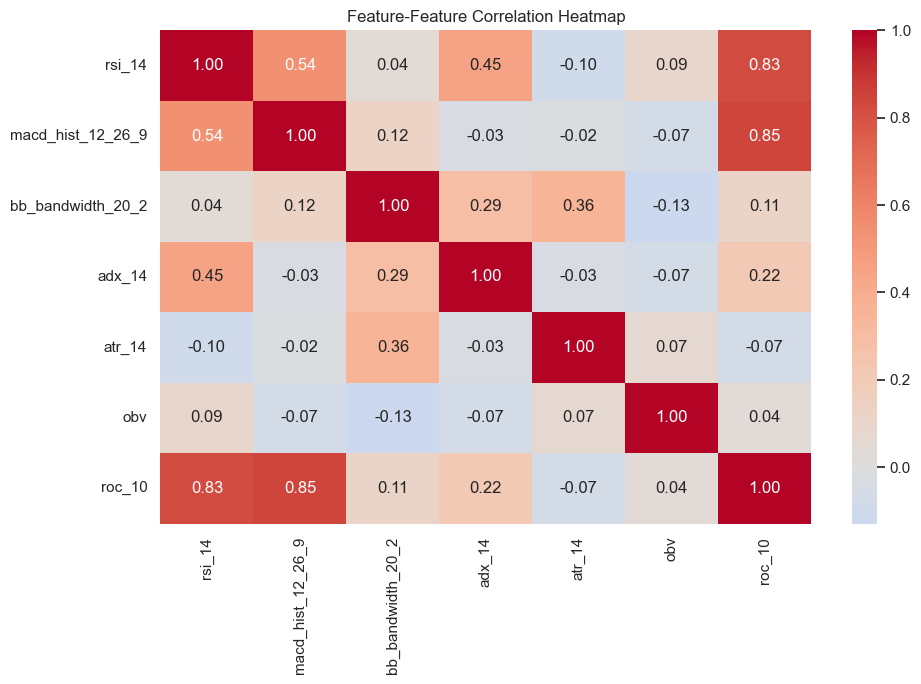

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature-Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Insight Justification: Multicollinearity Check

The heatmap is used to identify redundant indicator pairs.
This helps keep later regression models stable and interpretable by avoiding highly overlapping predictors.


## 5) Trend and Pattern Discovery

Visual trend analysis improves the quality of interpretation in the report. We examine:
- Smoothed vs actual adjusted close over time.
- Feature regime behavior (e.g., ADX trend-strength regimes).
- Scatter relationships against target to evaluate linear suitability.


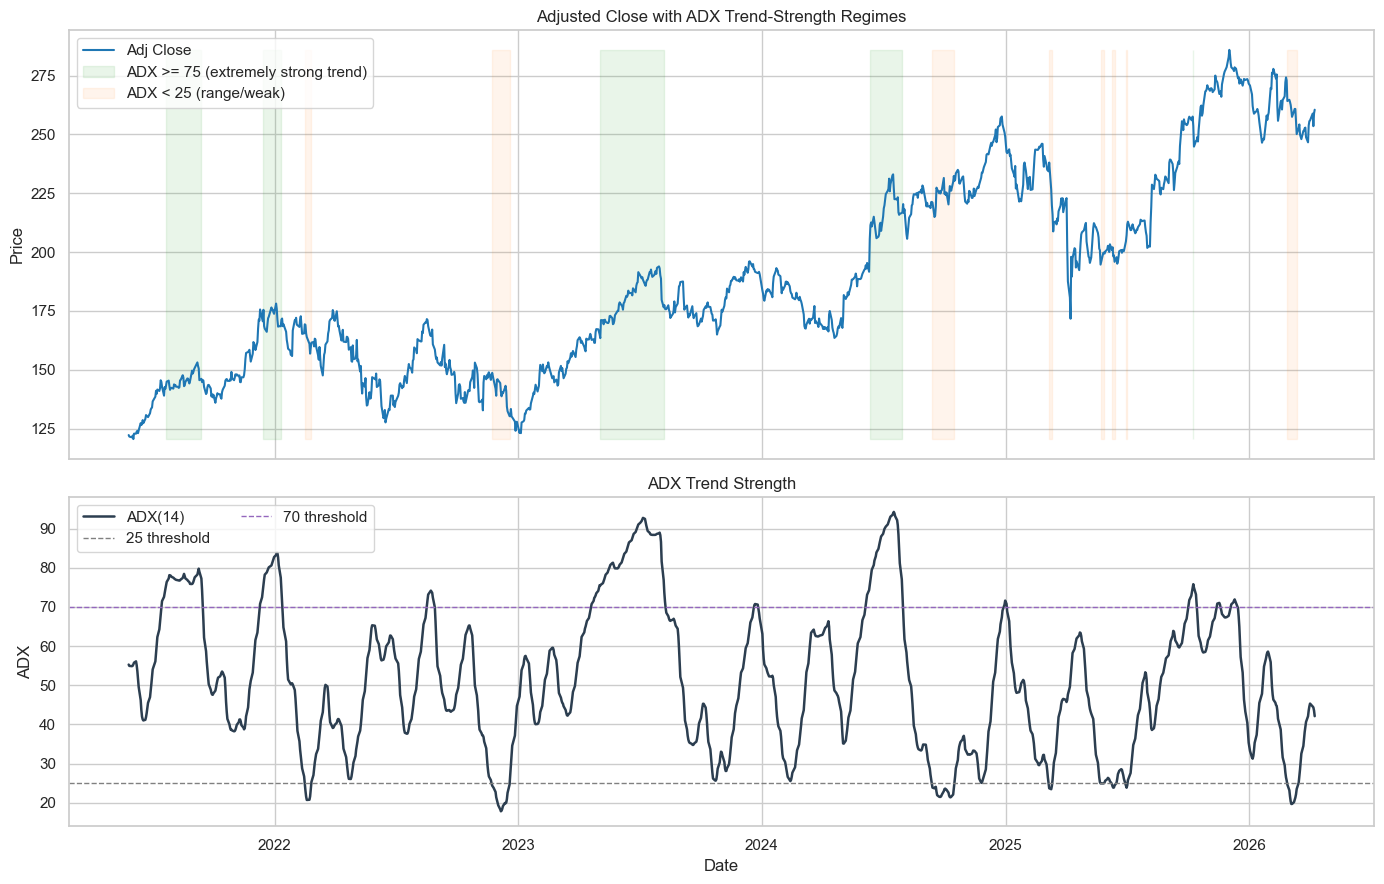

,observations,mean_return_pct,median_return_pct,return_std_pct
adx_regime,,,,
<25 weak,75,-0.2868,-0.2178,1.7278
25-50 strong,545,-0.0128,0.0686,1.7376
50-75 very strong,447,0.2531,0.1794,1.8336
>75 extremely strong,155,0.0601,0.1095,1.3613


In [ ]:
# ADX visualization (Investopedia-style strength interpretation)
# ADX is non-directional: it measures trend strength, not up/down direction.
# Common interpretation: <20 weak/range, >25 stronger trend, >50 very strong trend.

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})

# Panel 1: Price with ADX regime shading
axes[0].plot(df.index, df["adj_close"], color="#1f77b4", linewidth=1.5, label="Adj Close")

strong = df["adx_14"] >= 75
weak = df["adx_14"] < 25

axes[0].fill_between(df.index, df["adj_close"].min(), df["adj_close"].max(), where=strong, color="#2ca02c", alpha=0.10, label="ADX >= 75 (extremely strong trend)")
axes[0].fill_between(df.index, df["adj_close"].min(), df["adj_close"].max(), where=weak, color="#ff7f0e", alpha=0.08, label="ADX < 25 (range/weak)")
axes[0].set_title("Adjusted Close with ADX Trend-Strength Regimes")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

# Panel 2: ADX with thresholds
axes[1].plot(df.index, df["adx_14"], color="#2c3e50", linewidth=1.8, label="ADX(14)")
axes[1].axhline(25, linestyle="--", color="gray", linewidth=1, label="25 threshold")
axes[1].axhline(70, linestyle="--", color="#9467bd", linewidth=1, label="70 threshold")
axes[1].set_title("ADX Trend Strength")
axes[1].set_ylabel("ADX")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

# Report-friendly ADX regime summary table
regime = pd.cut(df["adx_14"], bins=[-np.inf, 25, 50, 75, np.inf], labels=["<25 weak", "25-50 strong", "50-75 very strong", ">75 extremely strong"])
regime_summary = (
    df.assign(adx_regime=regime)
      .groupby("adx_regime", observed=False)
      .agg(
          observations=("target_ret_1d_pct", "size"),
          mean_return_pct=("target_ret_1d_pct", "mean"),
          median_return_pct=("target_ret_1d_pct", "median"),
          return_std_pct=("target_ret_1d_pct", "std"),
      )
      .round(4)
)
regime_summary

### Insight Justification: ADX Strength + Direction

Following Investopedia guidance, ADX is used as a **trend-strength** gauge (non-directional), while `+DI` and `-DI` provide directional context.
- `ADX > 25` typically indicates a stronger trend regime.
- `+DI > -DI` suggests upward directional dominance; the reverse suggests downward dominance.

The accompanying regime summary table translates indicator behavior into report-ready return statistics by ADX strength bucket.


## 6) RSI and MACD Event Highlight Analysis

This section visualizes technical indicator states directly against price behavior for clearer trend interpretation.


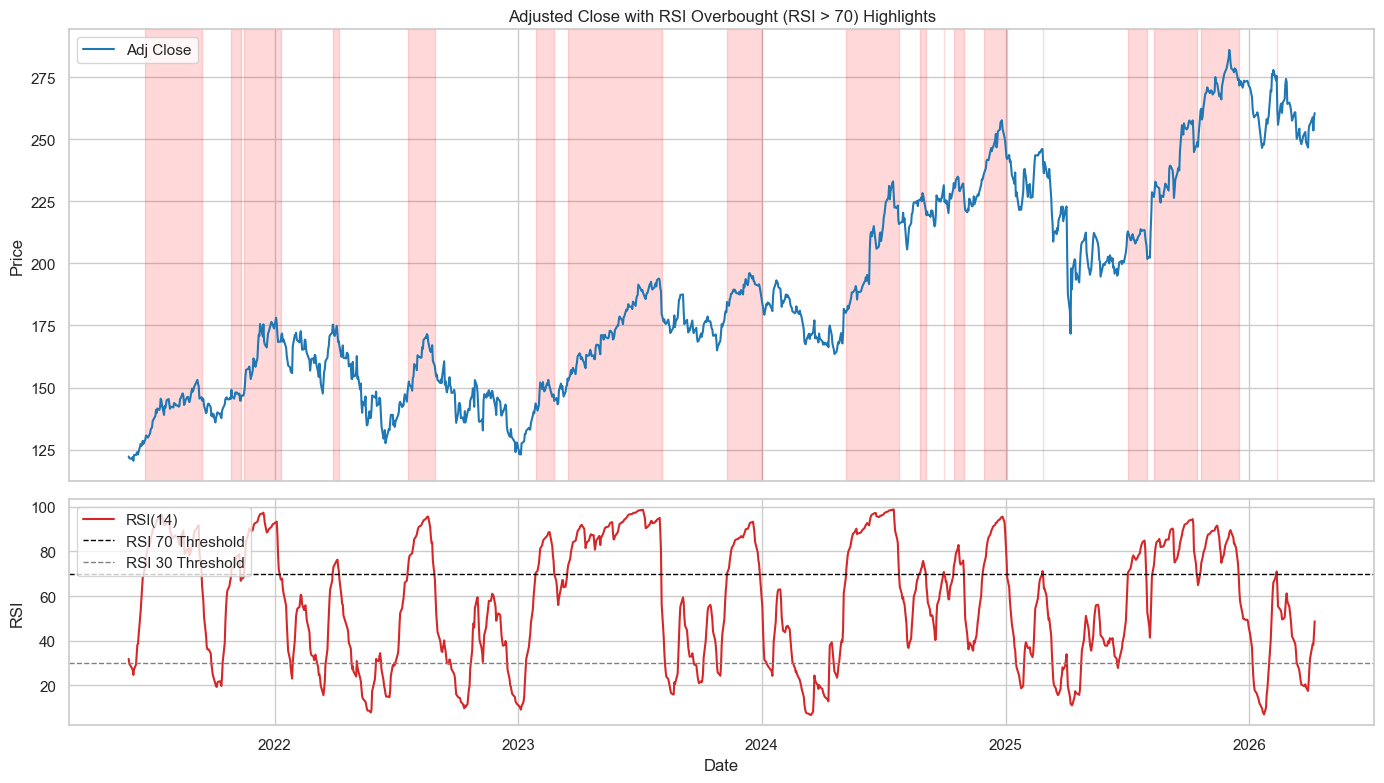

In [ ]:
# RSI vs price with overbought highlight (RSI > 70)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(df.index, df["adj_close"], color="#1f77b4", label="Adj Close")
axes[0].set_title("Adjusted Close with RSI Overbought (RSI > 70) Highlights")
axes[0].set_ylabel("Price")

rsi_overbought = df["rsi_14"] > 70
if rsi_overbought.any():
    start = None
    for idx, flag in rsi_overbought.items():
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            axes[0].axvspan(start, idx, color="red", alpha=0.15)
            start = None
    if start is not None:
        axes[0].axvspan(start, df.index[-1], color="red", alpha=0.15)

axes[1].plot(df.index, df["rsi_14"], color="#d62728", label="RSI(14)")
axes[1].axhline(70, linestyle="--", color="black", linewidth=1, label="RSI 70 Threshold")
axes[1].axhline(30, linestyle="--", color="gray", linewidth=1, label="RSI 30 Threshold")
axes[1].set_ylabel("RSI")
axes[1].set_xlabel("Date")

axes[0].legend(loc="upper left")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

### Insight Justification: RSI Overbought Windows

RSI-over-70 windows can indicate stretched momentum conditions.
Overlaying these windows on price helps discuss whether local pullbacks or continued momentum were more common in this dataset.


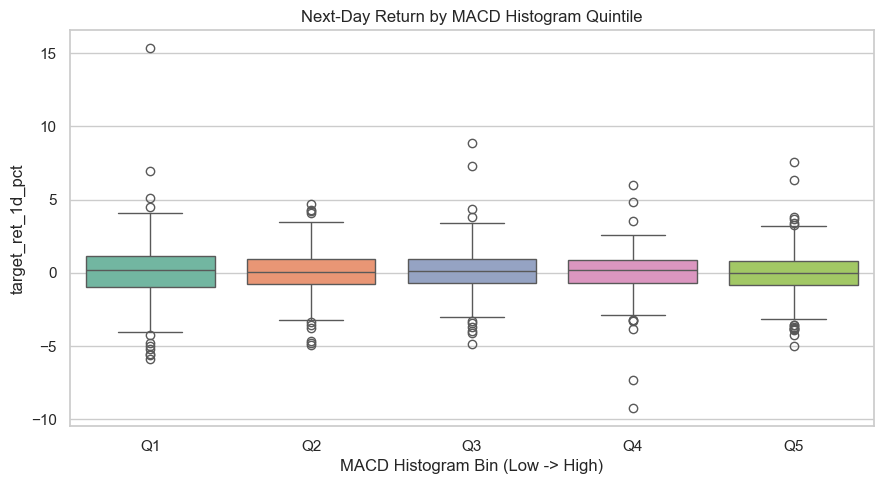

In [ ]:
# MACD relationship with next-day return (quintile boxplot only)
macd_bins = pd.qcut(df["macd_hist_12_26_9"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")
plot_df = df[["target_ret_1d_pct"]].copy()
plot_df["macd_bin"] = macd_bins

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="macd_bin", y="target_ret_1d_pct", hue="macd_bin", palette="Set2", legend=False)
plt.title("Next-Day Return by MACD Histogram Quintile")
plt.xlabel("MACD Histogram Bin (Low -> High)")
plt.ylabel("target_ret_1d_pct")
plt.tight_layout()
plt.show()

### Insight Justification: MACD Quintile Comparison

The quintile boxplot is easier to interpret than a dense scatter in noisy financial data.
It shows how next-day return distribution shifts from low to high MACD states, including median movement, spread, and outlier behavior in each momentum regime.


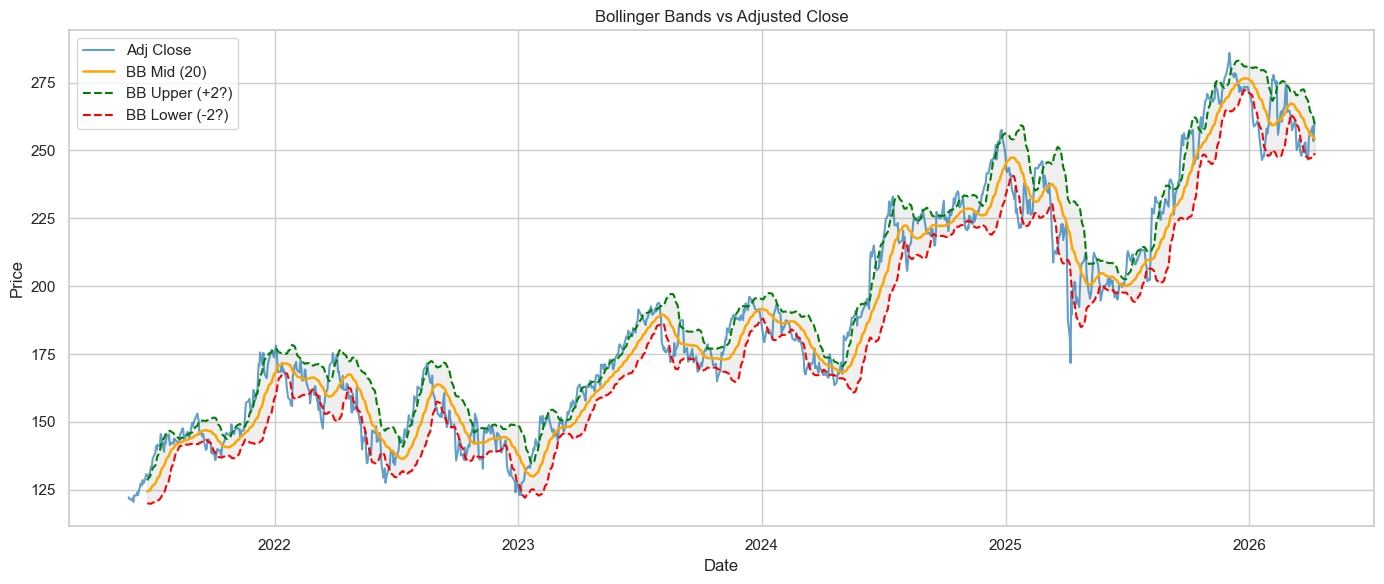

In [ ]:
# Bollinger Bands (20,2) against adjusted close
rolling_mid = df["adj_close_smooth"].rolling(window=20).mean()
rolling_std = df["adj_close_smooth"].rolling(window=20).std()
bb_upper = rolling_mid + 2 * rolling_std
bb_lower = rolling_mid - 2 * rolling_std

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["adj_close"], label="Adj Close", color="#1f77b4", alpha=0.7)
ax.plot(df.index, rolling_mid, label="BB Mid (20)", color="orange", linewidth=1.8)
ax.plot(df.index, bb_upper, label="BB Upper (+2?)", color="green", linestyle="--")
ax.plot(df.index, bb_lower, label="BB Lower (-2?)", color="red", linestyle="--")
ax.fill_between(df.index, bb_lower, bb_upper, color="gray", alpha=0.12)
ax.set_title("Bollinger Bands vs Adjusted Close")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Insight Justification: Bollinger Band Context

Bollinger bands provide a volatility envelope around trend.
Price interactions with upper/lower bands help discuss potential overextension, compression phases, and volatility expansions.


## 7) EDA Interpretation Notes for Report Writing

Use this section to summarize Chapter 3 insights in your report:

1. Statistical profile:
   - Describe central tendency and dispersion of `target_ret_1d_pct`.
   - Mention any visible skewness and outliers.

2. Feature behavior:
   - Highlight which indicators are stable vs highly volatile.
   - Note any non-Gaussian feature distributions.

3. Correlation findings:
   - Report strongest positive/negative feature-target relationships.
   - Discuss whether correlations are weak/moderate/strong and implications for linear regression.

4. Regime insights:
   - Explain how target distribution differs between trending and ranging periods (ADX regimes).

5. Model implication:
   - If relationships appear weakly linear or regime-dependent, note this as motivation for comparing additional models in later chapters.
